# Heart Disease Risk Prediction

## Introductory context
Heart disease is the world's leading cause of death, claiming approximately 18 million lives each year, as reported by the World Health Organization. Predictive models like logistic regression can enable early identification of at-risk patients by analyzing clinical features such as age, cholesterol, and blood pressure. This not only improves treatment outcomes but also optimizes resource allocation in healthcare settings.

## Step 1: Load and prepare the dataset

In [165]:
%pip install numpy matplotlib pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [166]:
import numpy as np
# Necessary to manipulate the tabular dataset
import pandas as pd
import matplotlib.pyplot as plt

In [167]:
# Loading dataset
DATA_PATH = "data/heart.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [168]:
# Binarize target: 1 = disease present, 0 = disease absent
df["target"] = (df["target"] > 0).astype(int)

# What values exist in the target column? 
print("Unique target values:", df["target"].unique())
# How many of each value?
print(df["target"].value_counts().sort_index())

# As a good practice, we are going to delete the duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

Unique target values: [0 1]
target
0    499
1    526
Name: count, dtype: int64
Shape after dropping duplicates: (302, 14)


### Exploratory Data Analysis (EDA)

In [169]:
# Type of data and number of non-null values in each column
print("Data types and non-null counts:")
print(df.info())

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB
None


In [170]:
#Summary statistics
print("Summary statistics:")
print(df.describe())

# Checking for missing values
print("\nMissing values:")
print(df.isnull().sum())

Summary statistics:
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.718543   
std      0.52602

In [171]:
# List of numeric columns we check for outliers
print("\nOutliers found: ")
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# We use the IQR (Interquartile Range) method, which is a standard and widely used technique to detect outliers
for col in numeric_cols:
    # Q1 = value below which 25% of the data falls
    # Q3 = value below which 75% of the data falls
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # IQR = the range where the "middle 50%" of the data lives
    iqr = q3 - q1

    # Standard rule (Tukey's rule): anything outside 1.5 * IQR from Q1/Q3 is considered an outlier. This 1.5 factor is the conventional
    # value used in boxplots and most statistical software.
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Filtering the rows where the column value falls outside [lower, upper]
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers found (normal range: {lower:.1f} to {upper:.1f})")


Outliers found: 
age: 0 outliers found (normal range: 28.5 to 80.5)
trestbps: 9 outliers found (normal range: 90.0 to 170.0)
chol: 5 outliers found (normal range: 115.4 to 370.4)
thalach: 1 outliers found (normal range: 84.1 to 215.1)
oldpeak: 5 outliers found (normal range: -2.4 to 4.0)


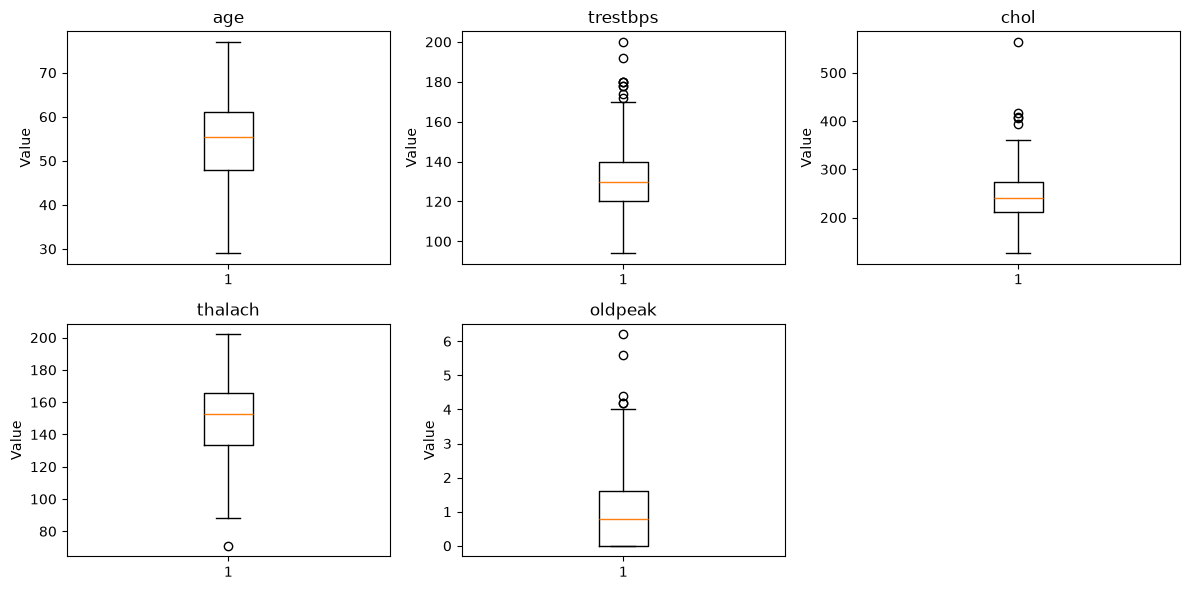

In [172]:
plt.figure(figsize=(12, 6))

for i, feature in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[feature])
    plt.title(feature)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

### Outlier detection

We checked for outliers using the **IQR (Interquartile Range) method**, which is a standard and common technique in exploratory data analysis. This method finds the middle 50% of the data (between the 25th and 75th percentile) and flags any value that falls far outside that range as a possible outlier. This is the same rule used by boxplots, so it is easy to visualize.

In our case, the dataset did not have any missing values, and the "outliers" we found (for example, very high cholesterol or blood pressure) are not data errors. They are extreme but medically possible values. Since this project is about predicting heart disease risk, these extreme values are important information: a very high cholesterol level can be exactly the kind of signal that indicates higher risk. For this reason, we did not remove or modify any outliers; we only report them here as part of the exploratory analysis.

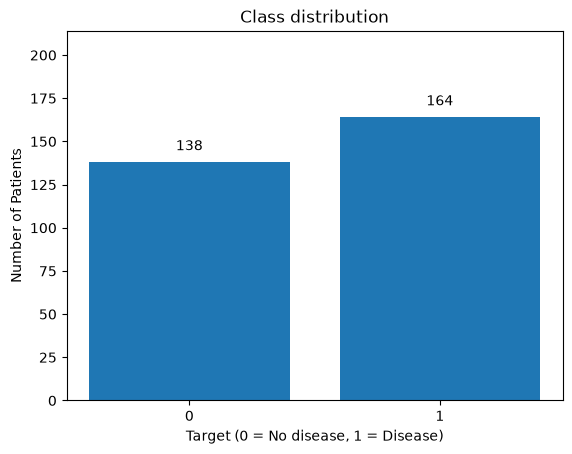

In [173]:
# Class distribution plot with exact counts labeled
counts = df["target"].value_counts().sort_index()

plt.figure()
bars = plt.bar(counts.index.astype(str), counts.values)

# Add the exact number on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,  # x position: center of the bar
              height + 5,                       # y position: just above the bar
              str(height),                       # the text to show
              ha="center", va="bottom")          # center-align horizontally

plt.xlabel("Target (0 = No disease, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.title("Class distribution")
plt.ylim(0, counts.max() + 50)  # extra space at top so the number isn't cut off
plt.show()

In [174]:
from sklearn.model_selection import train_test_split

# Separate features (X) from the target (y)
X = df.drop(columns=["target"])
y = df["target"]

# Stratified split: keeps the same proportion of class 0/1 in both train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print("Train shape:", X_train.shape)  
print("Test shape:", X_test.shape)   

# Normalizing values
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

Train shape: (211, 13)
Test shape: (91, 13)


We are going to select six features, the same features suggested in the assignment: age, cholesterol, blood pressure, maximum heart rate, ST depression and number of vessels.

In [175]:
selected_features = ["age", "chol", "trestbps", "thalach", "oldpeak", "ca"]

X_train_sel = X_train_norm[selected_features]
X_test_sel = X_test_norm[selected_features]

print("X_train_sel shape:", X_train_sel.shape)  
print("X_test_sel shape:", X_test_sel.shape)   

X_train_sel shape: (211, 6)
X_test_sel shape: (91, 6)


## Data insights and preprocessing decisions

The dataset was explored to understand its main characteristics before training the model. The target variable was converted into two classes: 0 for patients without heart disease and 1 for patients with heart disease.

Duplicate records were checked before the analysis. Exact duplicates were removed to avoid giving repeated observations more influence during model training. Removing duplicates before the train/test split also reduces the risk of having identical records in both sets. Otherwise, the model could be evaluated on observations that are the same as examples already seen during training, which could make the test results look better than they really are. After removing the duplicates, 302 unique records remained.

Possible outliers were analyzed in the continuous numerical features using the IQR method and boxplots. Some unusual values were found, but they were not automatically removed because they can represent real patients and may contain useful information for heart disease prediction. The ca feature was analyzed separately because it represents a discrete number of major vessels.

The target distribution showed 138 patients without heart disease and 164 patients with heart disease, so the two classes are relatively balanced.

For the model, six features were selected: age, cholesterol (chol), resting blood pressure (trestbps), maximum heart rate (thalach), ST depression (oldpeak), and number of major vessels (ca).

The dataset was divided into 70% training data and 30% test data using a stratified split. This keeps a similar proportion of patients with and without heart disease in both sets.

The selected features have very different scales. For example, cholesterol can have values in the hundreds, while `oldpeak` and `ca` have much smaller values. For this reason, the features were standardized using their mean and standard deviation.

The mean and standard deviation were calculated only from the training data and then used to transform both the training and test sets. This keeps the test set independent from the preparation of the model and gives a more realistic evaluation with data that was not used during training.


___
## Step 2: Implement basic Logistic Regression

In [176]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1+np.exp(-z))

In [177]:
def compute_cost(w, b, X, y):
    m = X.shape[0]

    z = X @ w + b
    f = sigmoid(z)

    eps = 1e-9  # small value to avoid log(0)
    f_clipped = np.clip(f, eps, 1-eps)
    J = -(1/m) * np.sum(y*np.log(f_clipped) + (1-y)*np.log(1-f_clipped))

    return J

In [178]:
def compute_gradient(w, b, X, y):
    m = X.shape[0]

    z = X @ w + b
    f = sigmoid(z)

    error = f - y
    dj_dw = (1/m) * X.T @ error
    dj_db = (1/m) * np.sum(error)

    return dj_dw, dj_db

In [179]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append((i + 1, compute_cost(w, b, X, y)))

        # Cost tracking
        if (i + 1) % 100 == 0:
            print(f"Iteration {i + 1}: Cost {J_history[-1][1]:.10f}")

    return w, b, J_history

In [180]:
# Training the model
alpha = 0.01
iterations = 1000
m, n = X_train_sel.shape
w_init = np.zeros(n)
b_init = 0.0

w, b, J_history = gradient_descent(X_train_sel.values, y_train.values, w_init, b_init, alpha, iterations)

Iteration 100: Cost 0.5958230005
Iteration 200: Cost 0.5520022048
Iteration 300: Cost 0.5290470728
Iteration 400: Cost 0.5155301537
Iteration 500: Cost 0.5068804159
Iteration 600: Cost 0.5010028006
Iteration 700: Cost 0.4968267555
Iteration 800: Cost 0.4937569028
Iteration 900: Cost 0.4914393078
Iteration 1000: Cost 0.4896520310


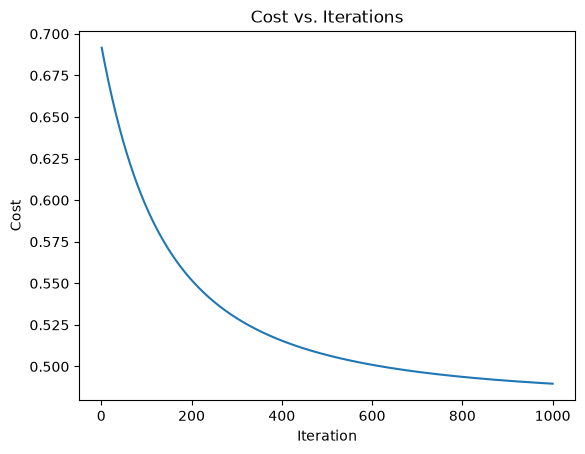

In [181]:
iterations_history = [it for it, cost in J_history]
cost_history = [cost for it, cost in J_history]

plt.plot(iterations_history, cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs. Iterations")
plt.show()

In [182]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(X @ w + b)
    return (probs >= threshold).astype(int)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))  # true positives
    tn = np.sum((y_pred == 0) & (y_true == 0))  # true negatives
    fp = np.sum((y_pred == 1) & (y_true == 0))  # false positives
    fn = np.sum((y_pred == 0) & (y_true == 1))  # false negatives

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

In [183]:
y_train_pred = predict(X_train_sel, w, b)
y_test_pred = predict(X_test_sel, w, b)

train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics = compute_metrics(y_test, y_test_pred)

metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1"],
    index=["Train", "Test"]
)
print(metrics_df.round(3))

       Accuracy  Precision  Recall     F1
Train     0.754      0.744   0.835  0.787
Test      0.791      0.800   0.816  0.808


### Model results and convergence

The cost decreases during training and gradually becomes more stable as the number of iterations increases. This indicates that gradient descent is converging: the model continues adjusting its parameters, but the improvement in the cost becomes smaller after many iterations. The smooth decrease also suggests that the learning rate of 0.01 is appropriate for this training process, since the cost does not show large oscillations or unstable behavior.

The training and test metrics are relatively close, which suggests that the model behaves similarly on the data used for training and on unseen test observations. Recall is also useful to consider in this problem because it represents the proportion of patients with heart disease that the model correctly identifies.

In [184]:
coefficients_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": w
})

coefficients_df["Abs. Coefficient"] = np.abs(coefficients_df["Coefficient"])
coefficients_df = coefficients_df.sort_values(
    by="Abs. Coefficient",
    ascending=False
)

coefficients_df

,Feature,Coefficient,Abs. Coefficient
3,thalach,0.691528,0.691528
5,ca,-0.636016,0.636016
4,oldpeak,-0.603699,0.603699
2,trestbps,-0.138581,0.138581
1,chol,-0.101923,0.101923
0,age,0.006681,0.006681



### Interpretation of the coefficients

Each coefficient represents the effect of one feature on the model output while the other selected features remain fixed. A positive coefficient increases the predicted probability of the positive class (`target = 1`), while a negative coefficient decreases it.

Since the features were standardized before training, their coefficient magnitudes can also be compared more easily. Features with larger absolute coefficients have a stronger effect on the linear part of this logistic regression model, while coefficients closer to zero have a smaller effect.

These coefficients should be interpreted as relationships learned by this particular model and not as direct medical or causal effects. The direction and magnitude of each coefficient can also depend on the other features included in the model.


___
## Step 3: Visualize Decision Boundaries

We are going to select three feature pairs for 2D decision boundary visualization:

In [185]:

feature_pairs = [
    ("age", "chol"),        # age vs cholesterol
    ("trestbps", "thalach"),  # blood pressure vs maximum heart rate
    ("oldpeak", "ca"),        # ST depression vs number of vessels
]

For each pair we are going to train the model and plot the decision boundary with true labels

In [192]:
def plot_linear_data_with_boundary(w, b, X, y, feature1, feature2):
    plt.figure(figsize=(7, 5))

    plt.scatter( X[y == 0, 0], X[y == 0, 1], marker="o", label="y = 0 (No disease)")

    plt.scatter( X[y == 1, 0], X[y == 1, 1], marker="x", label="y = 1 (Disease)")

    x1_vals = np.linspace( X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

    if abs(w[1]) > 1e-6:
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        plt.plot( x1_vals, x2_vals, "k--", label="Decision boundary")
    else:
        x1_line = -b / w[0]
        plt.axvline( x1_line, color="k", linestyle="--", label="Decision boundary")

    plt.title(f"{feature1} vs {feature2}")
    plt.xlabel(f"{feature1} (standardized)")
    plt.ylabel(f"{feature2} (standardized)")
    plt.legend()
    plt.show()

In [195]:
def feature_pairs_to_plot(f1, f2): 
    # Subset to these 2 features only
    X_pair = X_train_norm[[f1, f2]].values

    # Train a fresh model with only these 2 features
    w_init = np.zeros(2)
    b_init = 0.0
    w_pair, b_pair, J_history_pair = gradient_descent( X_pair, y_train.values, w_init, b_init, alpha=0.1, num_iters=2000)

    plot_linear_data_with_boundary( w_pair, b_pair, X_pair, y_train.values, f1, f2)

Iteration 100: Cost 0.6681549473
Iteration 200: Cost 0.6679772338
Iteration 300: Cost 0.6679745276
Iteration 400: Cost 0.6679744698
Iteration 500: Cost 0.6679744684
Iteration 600: Cost 0.6679744684
Iteration 700: Cost 0.6679744684
Iteration 800: Cost 0.6679744684
Iteration 900: Cost 0.6679744684
Iteration 1000: Cost 0.6679744684
Iteration 1100: Cost 0.6679744684
Iteration 1200: Cost 0.6679744684
Iteration 1300: Cost 0.6679744684
Iteration 1400: Cost 0.6679744684
Iteration 1500: Cost 0.6679744684
Iteration 1600: Cost 0.6679744684
Iteration 1700: Cost 0.6679744684
Iteration 1800: Cost 0.6679744684
Iteration 1900: Cost 0.6679744684
Iteration 2000: Cost 0.6679744684


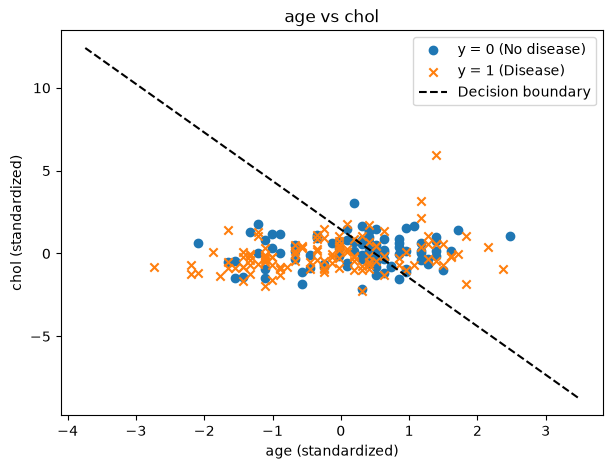

In [196]:
f1, f2 = feature_pairs[0] 
feature_pairs_to_plot(f1, f2)

The two classes show considerable overlap when only age and cholesterol are used. The decision boundary separates some observations, but many patients from both classes remain on both sides of the line. This suggests that these two features alone are not enough to clearly distinguish patients with and without heart disease.

The final cost also remains relatively high compared with the other feature pairs, which supports the visual observation that the classes are not strongly linearly separable using only age and cholesterol.

Iteration 100: Cost 0.5762272939
Iteration 200: Cost 0.5732768968
Iteration 300: Cost 0.5731117591
Iteration 400: Cost 0.5731008800
Iteration 500: Cost 0.5731001332
Iteration 600: Cost 0.5731000813
Iteration 700: Cost 0.5731000777
Iteration 800: Cost 0.5731000775
Iteration 900: Cost 0.5731000775
Iteration 1000: Cost 0.5731000775
Iteration 1100: Cost 0.5731000775
Iteration 1200: Cost 0.5731000775
Iteration 1300: Cost 0.5731000775
Iteration 1400: Cost 0.5731000775
Iteration 1500: Cost 0.5731000775
Iteration 1600: Cost 0.5731000775
Iteration 1700: Cost 0.5731000775
Iteration 1800: Cost 0.5731000775
Iteration 1900: Cost 0.5731000775
Iteration 2000: Cost 0.5731000775


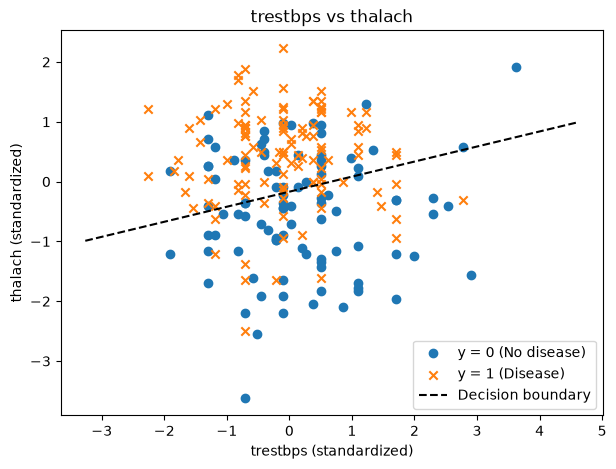

In [197]:
f1, f2 = feature_pairs[1]
feature_pairs_to_plot(f1, f2)

Resting blood pressure and maximum heart rate provide some separation between the classes, but there is still substantial overlap. The decision boundary captures a general tendency in the data, although many observations cannot be correctly separated using a single straight line.

The final cost is slightly lower than for the age–cholesterol pair, suggesting that these two features contain somewhat more useful information for classification, but they are still not enough to produce a clear separation by themselves.

Iteration 100: Cost 0.5400338595
Iteration 200: Cost 0.5361745078
Iteration 300: Cost 0.5358677173
Iteration 400: Cost 0.5358360365
Iteration 500: Cost 0.5358325004
Iteration 600: Cost 0.5358320953
Iteration 700: Cost 0.5358320485
Iteration 800: Cost 0.5358320430
Iteration 900: Cost 0.5358320424
Iteration 1000: Cost 0.5358320423
Iteration 1100: Cost 0.5358320423
Iteration 1200: Cost 0.5358320423
Iteration 1300: Cost 0.5358320423
Iteration 1400: Cost 0.5358320423
Iteration 1500: Cost 0.5358320423
Iteration 1600: Cost 0.5358320423
Iteration 1700: Cost 0.5358320423
Iteration 1800: Cost 0.5358320423
Iteration 1900: Cost 0.5358320423
Iteration 2000: Cost 0.5358320423


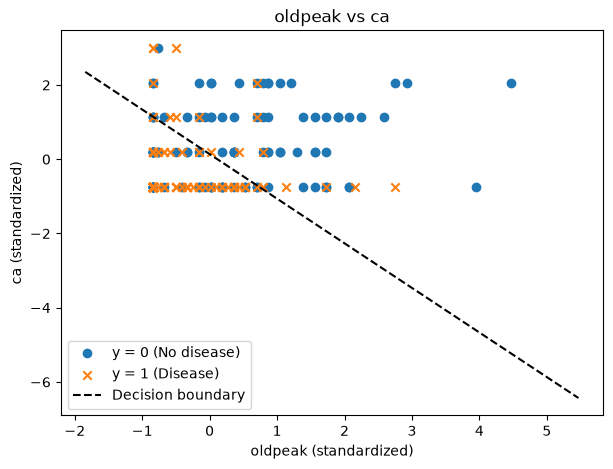

In [198]:
f1, f2 = feature_pairs[2]
feature_pairs_to_plot(f1, f2)

The combination of ST depression (oldpeak) and number of major vessels (ca) shows a clearer separation between the two classes compared with the previous feature pairs. Although there is still overlap and the separation is not perfect, the decision boundary appears to distinguish a larger proportion of the observations.

This pair also reaches the lowest final cost among the three models, suggesting that these two features provide more useful information for distinguishing between the two target classes.

None of the three feature pairs produces perfect linear separation. Patients from both classes appear on both sides of the decision boundaries, showing that heart disease prediction cannot be explained well by only two features at a time.

Among the selected pairs, oldpeak and ca provide the clearest separation and the lowest training cost. The remaining overlap also suggests that a simple linear boundary may not capture all the patterns in the data. Some relationships may depend on additional features or may not be completely linear.

___
## Step 4: 

In [188]:
def sigmoid(z):
    z = np.clip(z, -500, 500)  # avoid overflow for very large |z|
    return 1 / (1 + np.exp(-z))

def compute_cost_log_reg_reg(w, b, X, y, lam):
    """Regularized logistic regression cost."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)
    ce = -(1 / m) * np.sum(y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped))
    reg = (lam / (2 * m)) * np.sum(w ** 2)   # <-- lambda/(2m) ||w||^2
    return ce + reg

def compute_gradient_log_reg_reg(w, b, X, y, lam):
    """Gradient of regularized logistic regression cost."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)
    error = f - y
    dj_dw = (1 / m) * (X.T @ error) + (lam / m) * w   
    dj_db = (1 / m) * np.sum(error)                     
    return dj_dw, dj_db

def gradient_descent_log_reg_reg(X, y, w_init, b_init, alpha, lam, num_iters):
    w = w_init.copy()
    b = b_init
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_log_reg_reg(w, b, X, y, lam)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append(compute_cost_log_reg_reg(w, b, X, y, lam))
    return w, b, J_history

In [189]:
lambdas = [0, 0.001, 0.01, 0.1, 1]
results = []

for lam in lambdas:
    w_init = np.zeros(X_train_sel.shape[1])
    b_init = 0.0
    w, b, J_history = gradient_descent_log_reg_reg(X_train_sel, y_train, w_init, b_init,
                                                     alpha=0.1, lam=lam, num_iters=2000)
    y_test_pred = predict(X_test_sel, w, b)
    acc, prec, rec, f1 = compute_metrics(y_test, y_test_pred)
    w_norm = np.linalg.norm(w)   # ||w||, the "size" of the weight vector
    results.append({"lambda": lam, "accuracy": acc, "precision": prec,
                     "recall": rec, "f1": f1, "||w||": w_norm, "final_cost": J_history[-1]})

results_df = pd.DataFrame(results)
print(results_df.round(4))

   lambda  accuracy  precision  recall      f1   ||w||  final_cost
0   0.000    0.7802     0.7843  0.8163  0.8000  1.5093      0.4816
1   0.001    0.7802     0.7843  0.8163  0.8000  1.5092      0.4817
2   0.010    0.7802     0.7843  0.8163  0.8000  1.5085      0.4817
3   0.100    0.7802     0.7843  0.8163  0.8000  1.5011      0.4822
4   1.000    0.7692     0.7800  0.7959  0.7879  1.4342      0.4868


In [190]:
feature_pairs = [("age", "chol"), ("trestbps", "thalach"), ("oldpeak", "ca")]

pair_results = []
for f1, f2 in feature_pairs:
    X_pair = X_train_norm[[f1, f2]].values
    for lam in lambdas:
        w, b, J_history = gradient_descent_log_reg_reg(X_pair, y_train, np.zeros(2), 0.0,
                                                         alpha=0.1, lam=lam, num_iters=2000)
        pair_results.append({"pair": f"{f1}-{f2}", "lambda": lam,
                              "||w||": np.linalg.norm(w), "final_cost": J_history[-1]})
print(pd.DataFrame(pair_results).round(4))

                pair  lambda   ||w||  final_cost
0           age-chol   0.000  0.4008      0.6680
1           age-chol   0.001  0.4008      0.6680
2           age-chol   0.010  0.4007      0.6680
3           age-chol   0.100  0.4000      0.6680
4           age-chol   1.000  0.3931      0.6683
5   trestbps-thalach   0.000  1.1273      0.5731
6   trestbps-thalach   0.001  1.1273      0.5731
7   trestbps-thalach   0.010  1.1269      0.5731
8   trestbps-thalach   0.100  1.1233      0.5734
9   trestbps-thalach   1.000  1.0893      0.5760
10        oldpeak-ca   0.000  1.2965      0.5358
11        oldpeak-ca   0.001  1.2964      0.5358
12        oldpeak-ca   0.010  1.2959      0.5359
13        oldpeak-ca   0.100  1.2913      0.5362
14        oldpeak-ca   1.000  1.2475      0.5397


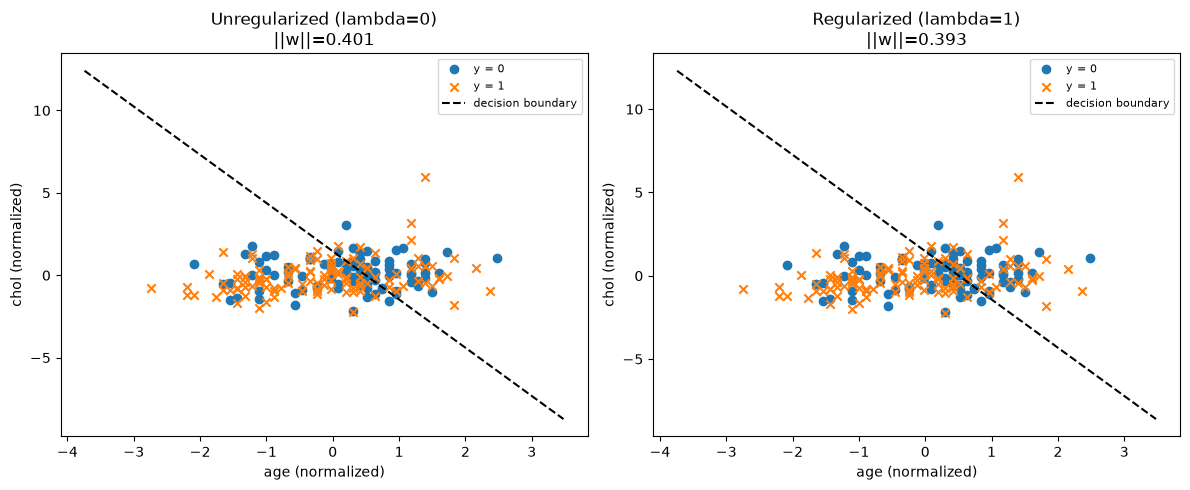

In [191]:
f1, f2 = "age", "chol"
X_pair = X_train_norm[[f1, f2]].values

w_unreg, b_unreg, _ = gradient_descent_log_reg_reg(X_pair, y_train, np.zeros(2), 0.0,
                                                     alpha=0.1, lam=0, num_iters=2000)
w_reg, b_reg, _ = gradient_descent_log_reg_reg(X_pair, y_train, np.zeros(2), 0.0,
                                                 alpha=0.1, lam=1, num_iters=2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (w, b, title) in zip(axes, [
    (w_unreg, b_unreg, f"Unregularized (lambda=0)\n||w||={np.linalg.norm(w_unreg):.3f}"),
    (w_reg, b_reg, f"Regularized (lambda=1)\n||w||={np.linalg.norm(w_reg):.3f}"),
]):
    ax.scatter(X_pair[y_train == 0, 0], X_pair[y_train == 0, 1], marker="o", label="y = 0")
    ax.scatter(X_pair[y_train == 1, 0], X_pair[y_train == 1, 1], marker="x", label="y = 1")
    x1_vals = np.linspace(X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1, 100)
    x2_vals = -(w[0] * x1_vals + b) / w[1]
    ax.plot(x1_vals, x2_vals, "k--", label="decision boundary")
    ax.set_title(title)
    ax.set_xlabel(f"{f1} (normalized)")
    ax.set_ylabel(f"{f2} (normalized)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()